# Analysis of factors and construction of a model for predicting the cost of housing in Moscow

# Анализ факторов и построение модели для предсказания стоимости жилья в Москве

# Data preparation and verification

# Подготовка и проверка данных

Import the required libraries

Импоритруем нужные библиотеки

In [2]:
import kagglehub
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as ss

Downloading a dataset from Kaggle

Скачиваем датасет с Kaggle

In [3]:
dataset_link = 'hugoncosta/price-of-flats-in-moscow'
dataset_path = kagglehub.dataset_download(dataset_link)
file_name = os.path.join(os.listdir(dataset_path)[0])

100%|██████████| 19.8k/19.8k [00:00<00:00, 16.0MB/s]

Extracting files...


Reading the table

Считаем таблицу

In [4]:
df = pd.read_csv(os.path.join(dataset_path, file_name))

1. price - price of the apartment in $1000
2. totsp - total area of ​​the apartment, sq.m.
3. livesp - living area of ​​the apartment, sq.m.
4. kitsp - kitchen area, sq.m.
5. dist - distance from the center in km.
6. metrdist - distance to the metro in minutes
7. walk - 1 – walk from the metro, 0 – by transport
8. brick1 – brick, monolithic reinforced concrete, 0 – other
9. floor - 1 – floor except the first and last, 0 – otherwise

==================================================================
1. price - цена квартиры в $1000
2. totsp - общая площадь квартиры, кв.м.
3. livesp -  жилая площадь квартиры, кв.м.
4. kitsp - площадь кухни, кв.м.
5. dist - расстояние от центра в км.
6. metrdist - расстояние до метро в минутах
7. walk - 1 – пешком от метро, 0 – на транспорте
8. brick1 – кирпичный, монолит ж/б, 0 – другой
9. floor - 1 – этаж кроме первого и последнего, 0 – иначе

Let's look at the data

Взгянем на данные

In [5]:
df.head()

,Unnamed: 0,price,totsp,livesp,kitsp,dist,metrdist,walk,brick,floor,code
0,1,81,58,40,6.0,12.5,7,1,1,1,3
1,2,75,44,28,6.0,13.5,7,1,0,1,6
2,3,128,70,42,6.0,14.5,3,1,1,1,3
3,4,95,61,37,6.0,13.5,7,1,0,1,1
4,5,330,104,60,11.0,10.5,7,0,1,1,3


Let's remove the unnecessary column, which essentially repeats the index, as well as the code column.

Удалим ненужный столбец, который по сути повторяет индекс, а также столбец code

In [6]:
df = df.drop(columns=['Unnamed: 0', 'code'])

Let's check the data types

Проверим типы данных

In [7]:
df.dtypes

,0
price,int64
totsp,int64
livesp,int64
kitsp,float64
dist,float64
metrdist,int64
walk,int64
brick,int64
floor,int64


Let's check if there are any missing values

Проверим есть ли пропущенные значения

In [8]:
df.isnull().sum()

,0
price,0
totsp,0
livesp,0
kitsp,0
dist,0
metrdist,0
walk,0
brick,0
floor,0


We have categorical data types in int format, let's check their unique values ​​just in case (there should only be 0 or 1)

Категориальные типы данных у нас формате int, проверим их уникальные зачения на всякий случай (должны быть только 0 или 1)

In [9]:
print(df.walk.unique())
print(df.brick.unique())
print(df.floor.unique())

[1 0]
[1 0]
[1 0]


Let's check for duplicates

Проверим наличие дубликатов

In [71]:
df.duplicated().sum() # I think 45 duplicates are not many, since some apartments may have similar characteristics | 45 дубликатов я думаю не много, так как квартиры некоторые могут совпадать по характеристикам

np.int64(45)

Let's build a heatmap to see which features are most correlated with others.

Построим heatmap, что бы посмотреть какие признаки больше всего кореллируются с другими

<Axes: >

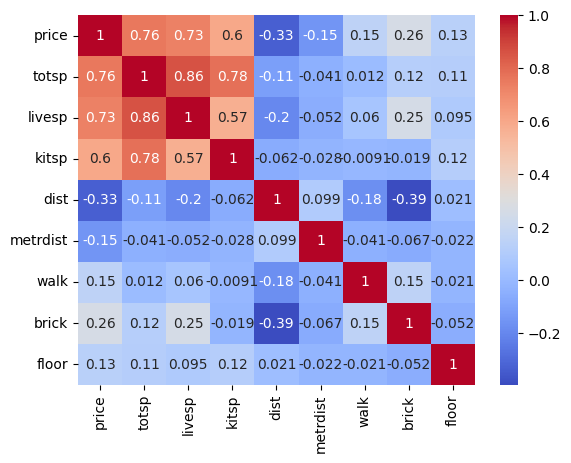

In [11]:
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")

And so we see that we have a large correlation for the first 4 features, and specifically we are interested in the correlation of different features with the price. Let's build scatterplots for features that are strongly correlated with the price

И так мы видим, что большая корелляция у нас по первым 4 признакам, а конкретно нас интересует корреляция разных признаков с ценой. Построим scatterplot'ы для признаков, которые сильно коррелируются с ценой

Correlation price and totsp:

<Axes: xlabel='price', ylabel='totsp'>

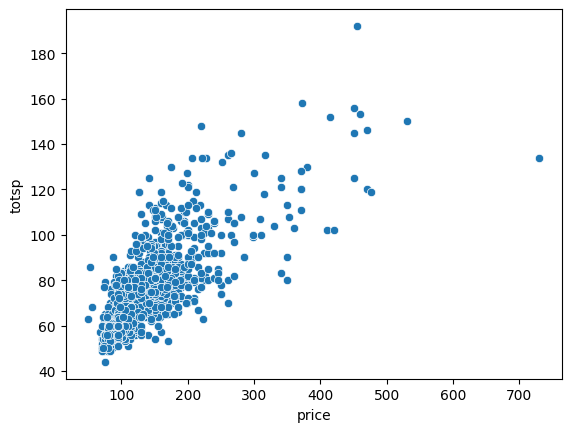

In [12]:
sns.scatterplot(x = df.price, y = df.totsp)

Correlation price and livesp:

<Axes: xlabel='price', ylabel='livesp'>

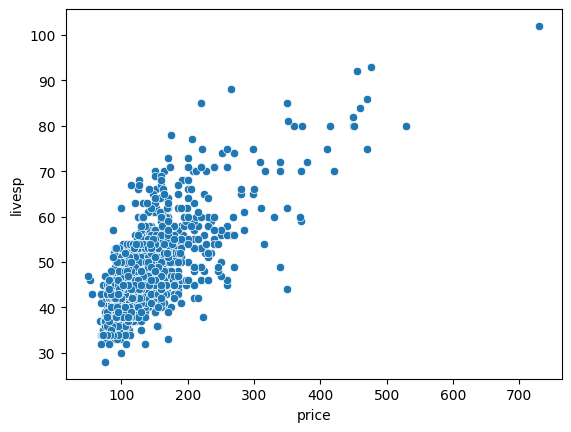

In [13]:
sns.scatterplot(x = df.price, y = df.livesp)

Correlation price and kitsp:

<Axes: xlabel='price', ylabel='kitsp'>

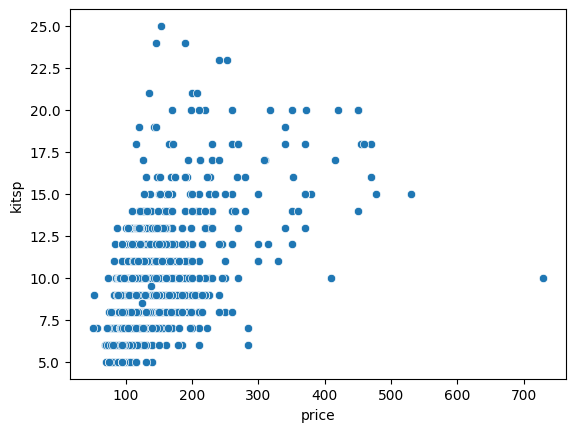

In [14]:
sns.scatterplot(x = df.price, y = df.kitsp)

We will also check the correlation with the dist feature. They have an inverse correlation according to the hitmap. Which is logical, since the price is higher the closer to the center (that is, the dist feature is lower, the price is higher)

Так же проверим корреляцию с признаком dist. У них по хитмапу обратная корреляция. Что логично, так как цена больше чем ближе к центру (то есть признак dist меньше, цена больше)

<Axes: xlabel='price', ylabel='dist'>

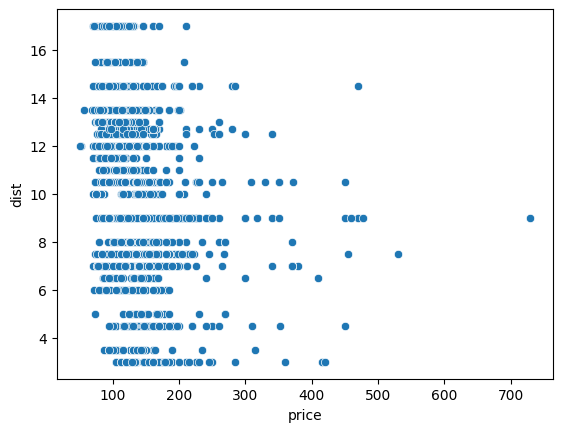

In [15]:
sns.scatterplot(x = df.price, y = df.dist)

And let's also look at the metrdist sign

А так же посмотрим на признак metrdist

<Axes: xlabel='price', ylabel='metrdist'>

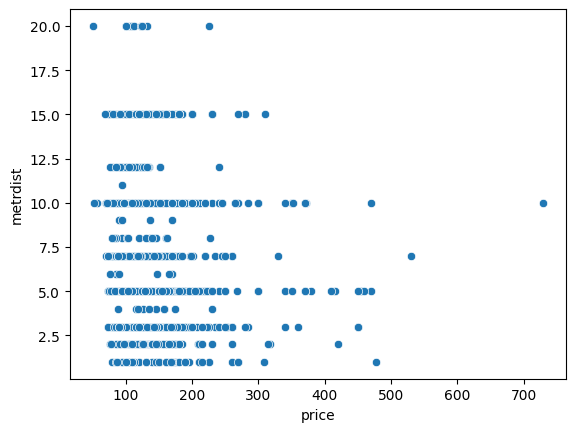

In [16]:
sns.scatterplot(x = df.price, y = df.metrdist)

Although not so obvious, there is a correlation between the features dist and metrdist, so I will leave them for training.

Хоть и не такая явная, но корреляция между признаками dist и metrdist наблюдается, по этому я оставлю их для обучения

All the graphs clearly show the price value, which strongly deviates from all other observations. Let's check it using boxplot:

На всех графиков отчетливо наблюдается значение price сильно отбивающееся от всех остальных наблюдений. Проверим с помощью boxplot:

<Axes: ylabel='price'>

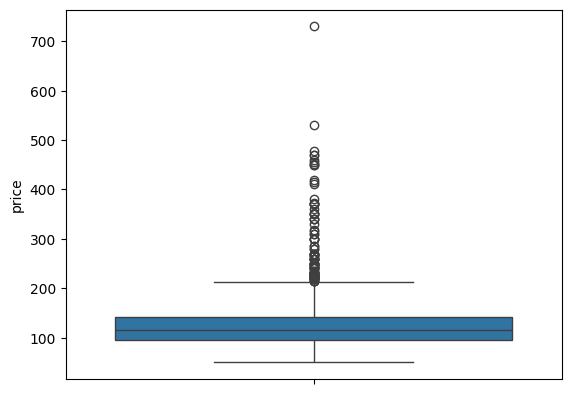

In [17]:
sns.boxplot(df['price'])

Let's find this potential outlier using sorting

Найдем этот потенциальный выброс с помощью сортировки:

In [18]:
df.sort_values('price', ascending=False)

,price,totsp,livesp,kitsp,dist,metrdist,walk,brick,floor
966,730,134,102,10.0,9.0,10,1,1,1
1656,530,150,80,15.0,7.5,7,1,1,1
1528,477,119,93,15.0,9.0,1,1,0,1
885,470,146,86,16.0,14.5,5,1,1,1
101,470,120,75,18.0,9.0,10,1,1,1
...,...,...,...,...,...,...,...,...,...
1141,70,52,34,6.0,12.0,10,1,0,0
1504,68,57,37,6.0,13.5,15,1,0,0
25,56,68,43,7.0,13.5,10,0,1,1
138,52,86,46,9.0,12.0,10,0,0,1


I won't rush to delete it for now. I'm interested in checking the model's performance with and without it, so I'll create a copy just in case.

Я пока что не буду торопится его удалять. Мне интересно проверить показатели модели с ним и без него, пока что создам копию на всякий случай

In [19]:
df1 = df[df.price != 730].copy()

Next, I want to check the average prices with grouping by categorical features and see their impact on the price, in order to understand whether to take these features into training.

Далее я хочу проверить средние цены с группировкой по категориальным признакам и посмотреть их влияние на цену, что бы понять брать ли эти признаки в обучение

In [20]:
df.groupby('walk').agg({'price': 'mean'})

,price
walk,
0,115.850234
1,132.832738


In [21]:
df.groupby('brick').agg({'price': 'mean'})

,price
brick,
0,118.151340
1,147.080425


In [22]:
df.groupby('floor').agg({'price': 'mean'})

,price
floor,
0,114.133489
1,131.034098


I would like to additionally conduct a ttest for each feature in order to accurately draw a conclusion about its statistical significance.

Хочу дополноительно провести ttest для каждого признака, что бы точно сделать вывод о его статистической значимости

And just in case, it is worth looking at the amount of data for each feature to check if there is an imbalance.

И на всякий случай стоит посмотреть количество данных для каждого признака, что бы проверить нет ли дизбаланса

In [23]:
print(df.groupby('walk').agg({'price': 'count'}))
print(df.groupby('floor').agg({'price': 'count'}))
print(df.groupby('brick').agg({'price': 'count'}))

      price
walk       
0       641
1      1399
       price
floor       
0        427
1       1613
       price
brick       
0       1381
1        659


As we can see, although there is an imbalance by eye, for statistics it is not an imbalance. If we recall the CLT, there should be at least 30 observations. However, for additional reliability it is better to use a t-test with an incomplete assumption of equality of variances ```(equal_var=False)```


Как видим хоть и на глаз есть дизбаланс, но для статистистики это не дизбаланс. Если вспомнить ЦПТ, то наблюдений должно быть хотя бы 30. Однако для дополнительной надежности лучше использовать t-тест с неполным допущением равенства дисперсий ```(equal_var=False)```

I will write a function that will accept a data frame and a feature category, perform a ttest and, based on the resulting p-value, check whether there are statistically significant differences between the groups by price.

Напишу функцию, которая будет принимать датафрейм и категорию признака, проводить ttest и по полученному p-value проверять есть ли статистически значимые различия между группами по цене

In [24]:
def feature_ttest(df, feature):
  group_1 = df[df[feature] == 0].price
  group_0 = df[df[feature] == 1].price
  p = ss.ttest_ind(group_1, group_0, equal_var=False)[1]
  print(f"p-value = {p:.4f} for {feature}")

In [25]:
feature_ttest(df, 'floor')
feature_ttest(df, 'walk')
feature_ttest(df, 'brick')

p-value = 0.0000 for floor
p-value = 0.0000 for walk
p-value = 0.0000 for brick


And so we are convinced of the statistical significance of the price differences for these categories. Therefore, we leave them for training.

И так мы убедились в статистической значимости различий цены для данных категорий. По этому оставляем их для обучения

And I won't forget about the table without outliers:

И не забуду про таблицу без выброса:

In [26]:
feature_ttest(df1, 'floor')
feature_ttest(df1, 'walk')
feature_ttest(df1, 'brick')

p-value = 0.0000 for floor
p-value = 0.0000 for walk
p-value = 0.0000 for brick


# Обучение модели

Let's import the dataset splitting tool from sklearn and split it

Импоритруем из sklearn интрумент для разбивки датасета и разобъем его

In [45]:
from sklearn.model_selection import train_test_split

X = df.drop('price', axis=1)
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

We import tools for linear regression and the required metrics. We will build a linear regression model

Импортируем инструменты для линейной регрессии и нужные метрики. Построим модель линейной регрессии

In [37]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

model_LR = LinearRegression()
model_LR.fit(X_train, y_train)

y_pred_LR = model_LR.predict(X_test)

print("R²:", r2_score(y_test, y_pred_LR))
print("MAE:", mean_absolute_error(y_test, y_pred_LR))
print("MSE:", mean_squared_error(y_test, y_pred_LR))

R²: 0.6468960672944799
MAE: 19.599518106393383
MSE: 1199.650112061415


Let's plot a graph of predicted and actual values, as well as a regression line:

Построим график предсказаныых и фактических значений, а так же линию регрессии:

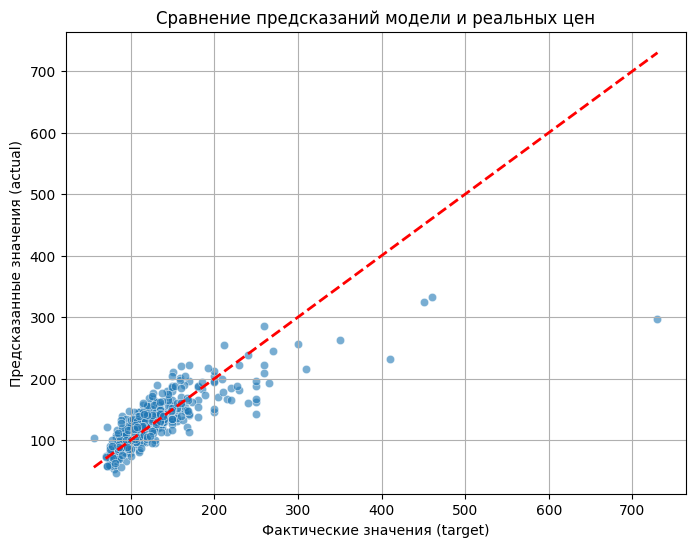

In [72]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred_LR, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2, linestyle='--')
plt.xlabel('Фактические значения (target)')
plt.ylabel('Предсказанные значения (actual)')
plt.title('Сравнение предсказаний модели и реальных цен')
plt.grid(True)
plt.show()

Now let's perform regression using random forest:

Теперь выполним регрессию при помощи случайного леса:

In [43]:
from sklearn.ensemble import RandomForestRegressor

model_RFR = RandomForestRegressor(n_estimators=100, random_state=42)
model_RFR.fit(X_train, y_train)
y_pred_RFR = model_RFR.predict(X_test)

print("R²:", r2_score(y_test, y_pred_RFR))
print("MAE:", mean_absolute_error(y_test, y_pred_RFR))
print("MSE:", mean_squared_error(y_test, y_pred_RFR))


R²: 0.7332756838976415
MAE: 16.350815398381574
MSE: 906.1803793857786


We also construct the same for a random forest:

Так же строим и для случайного леса:

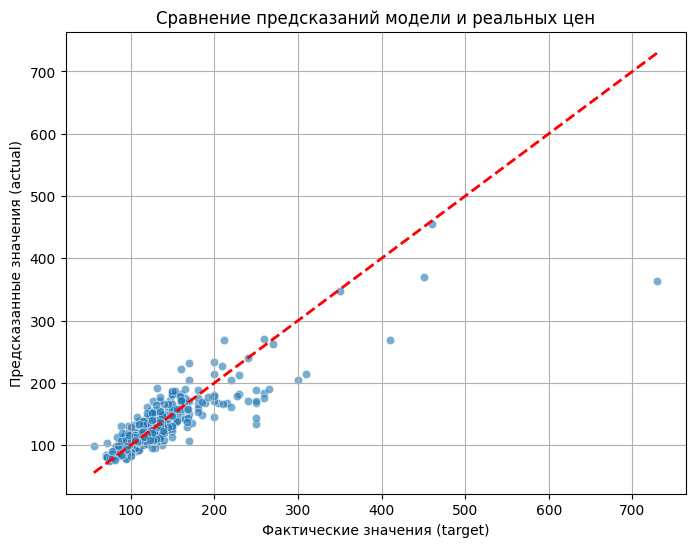

In [73]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred_RFR, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2, linestyle='--')
plt.xlabel('Фактические значения (target)')
plt.ylabel('Предсказанные значения (actual)')
plt.title('Сравнение предсказаний модели и реальных цен')
plt.grid(True)
plt.show()

As we can see from the R square, MSE, MAE indicators, the random forest did better.
1. R square (determination coefficient) - the closer to 1, the better (stronger the dependence).
2. MAE (mean absolute error) - in our case, the average error in price, which is about 3.2 thousand less for the random forest
3. MSE (root mean square error) - the difference between the predicted and predicted values ​​squared. The smaller the better

And if you look at the graph, you can see that the prediction/actual points are closer to the red line (ideal values) for the random forest

===========================================================================

Как видим по показателям R квадрат, MSE, MAE случайный лес справился лучше.
1. R квадрат (коэффициент детерминации) - чем ближе к 1 тем лучше (сильнее зависимость).
2. MAE (средняя абсолютная ошибка) - в нашем случае средняя ошибка в цене, которая у случайного леса примерно на 3.2 тысячи меньше
3. MSE (среднеквадратичная ошибка) - разница между прогнозируемыми и предсказанными значениями возведенная в квадрат. Чем меньше тем лучше

И если посмотреть на график, то видно, что точки предсказания/фактические лежат ближе к красной линии (идеальным зачениям) при случайном лесе

===========================================================================

These prediction graphs still show that same outlier that haunts me. Let's train models on a dataset without that outlier and analyze the results.

На этих графиках предсказаний все еще видно тот самый быброс, который мне не дает покоя. Обучим модели на датасете без этого выброса и проанализируем результат

In [47]:
X1 = df1.drop('price', axis=1)
y1 = df1['price']

X_train1, X_test1, y_train1, y_test1 = train_test_split(X1, y1, test_size=0.2, random_state=42)

In [48]:
model_LR1 = LinearRegression()
model_LR1.fit(X_train1, y_train1)

y_pred_LR1 = model_LR.predict(X_test1)

print("R²:", r2_score(y_test1, y_pred_LR1))
print("MAE:", mean_absolute_error(y_test1, y_pred_LR1))
print("MSE:", mean_squared_error(y_test1, y_pred_LR1))

R²: 0.7103373651066012
MAE: 17.84617840665166
MSE: 664.662146929829


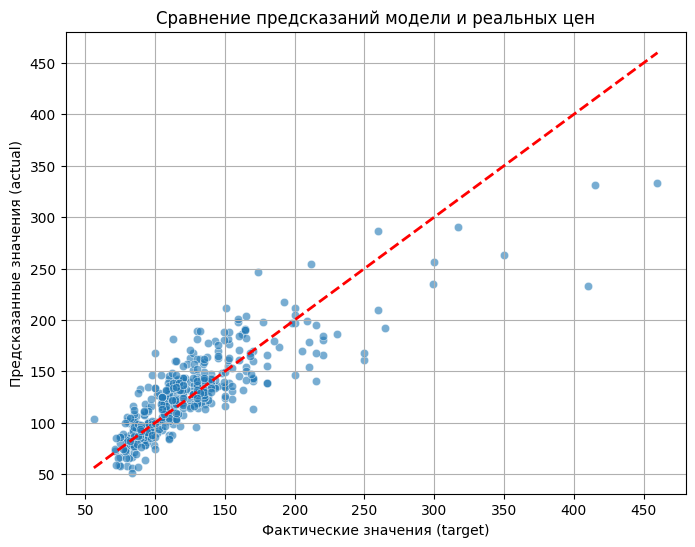

In [74]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test1, y=y_pred_LR1, alpha=0.6)
plt.plot([y_test1.min(), y_test1.max()], [y_test1.min(), y_test1.max()], color='red', lw=2, linestyle='--')
plt.xlabel('Фактические значения (target)')
plt.ylabel('Предсказанные значения (actual)')
plt.title('Сравнение предсказаний модели и реальных цен')
plt.grid(True)
plt.show()

In [50]:
model_RFR1 = RandomForestRegressor(n_estimators=100, random_state=42)
model_RFR1.fit(X_train1, y_train1)
y_pred_RFR1 = model_RFR1.predict(X_test1)

print("R²:", r2_score(y_test1, y_pred_RFR1))
print("MAE:", mean_absolute_error(y_test1, y_pred_RFR1))
print("MSE:", mean_squared_error(y_test1, y_pred_RFR1))


R²: 0.7783276792623302
MAE: 14.507485790149392
MSE: 508.6510404444816


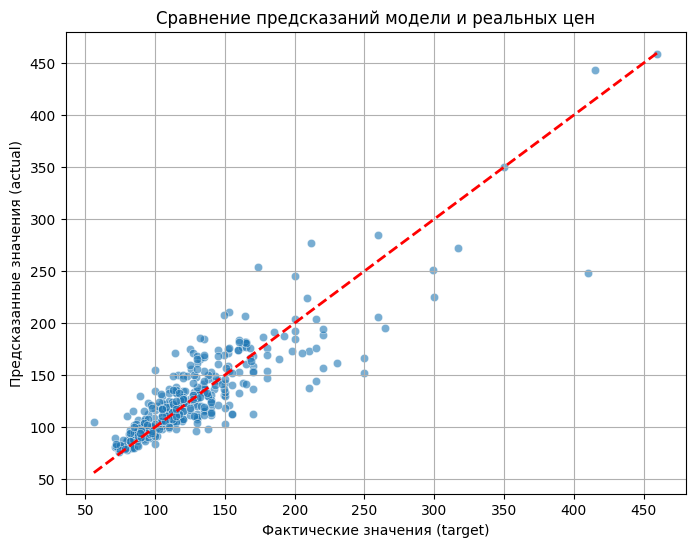

In [75]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test1, y=y_pred_RFR1, alpha=0.6)
plt.plot([y_test1.min(), y_test1.max()], [y_test1.min(), y_test1.max()], color='red', lw=2, linestyle='--')
plt.xlabel('Фактические значения (target)')
plt.ylabel('Предсказанные значения (actual)')
plt.title('Сравнение предсказаний модели и реальных цен')
plt.grid(True)
plt.show()

I will construct a table for convenience.

Построю для удобства таблицу

In [63]:
table_ = pd.DataFrame({
    'Модель' : ['Линейная', 'Случайный лес'],
    'R квадрат (выброс)' : [0.647, 0.733],
    'R квадрат (без выброса)' : [0.710, 0.778],
    'Разинца R квадрат' : [0.063, 0.045],
    'MAE (выброс)' : [19.6, 16.35],
    'MAE (без выброса)' : [17.85, 14.51],
    'Разница MAE' : [-1.75, -1.84],
    'MSE (выброс)' : [1199, 906],
    'MSE (без выброса)' : [664, 508],
    'Разница MSE' : [-535, -398]
})
table_

,Модель,R квадрат (выброс),R квадрат (без выброса),Разинца R квадрат,MAE (выброс),MAE (без выброса),Разница MAE,MSE (выброс),MSE (без выброса),Разница MSE
0,Линейная,0.647,0.710,0.063,19.60,17.85,-1.75,1199,664,-535
1,Случайный лес,0.733,0.778,0.045,16.35,14.51,-1.84,906,508,-398


And as we see, all the indicators have improved for both models. Overall, significantly, considering that we removed only one value. The indicators have improved more for simple linear regression, since it is more sensitive to outliers.

И так как видим все показатели улучшились по обоим моделям. В целом значительно, учитывая, что мы удалили всего одно значение. Больше показатели улучшились у простой линейной регрессии, так как она более чувствительная к выбросам